### There are several ways to establish connection to local postgresql db but we will use pandas and sqlalchemy libraries

### To install it RUN THE NEXT CELL BY CLICKING ON IT AND SHIFT+ENTER or click RUN BUTTON ABOVE

In [12]:
!pip install pandas sqlalchemy


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### As now we have proper libraries we can import and use them 

### Execute the following cell 

In [13]:
import pandas as pd
from sqlalchemy import create_engine

def connect_to_db(dbname: str, user: str, password: str, host: str = "localhost", port: str = "5432"):
    try:
        conn_str = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"
        engine = create_engine(conn_str)
        print(f"Engine created for database: {dbname}")
        return engine
    except Exception as e:
        print(f"Error creating engine for {dbname}: {e}")
        return None


### in previous cell we creted connect_to_db function which we can reuse to connect to both of our DBs, we just need to provide propper attributers. 

### In the next cell you can find example of establishing connection to SRC DB and reading data from s1.s1_channels into separate pandas dataframe

### Execute the following cell 

In [14]:
src_engine = connect_to_db(
    dbname="dwh_src_hw_db",
    user="postgres",
    password="postgres",
    port="5433"
)

s1_channels_df = pd.read_sql("SELECT * FROM s1.s1_channels", src_engine)
s1_channels_df

Engine created for database: dwh_src_hw_db


,channel_id,channel_name,channel_location
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
153,154,YAOBAO.COM,Internet
154,155,CATALOG.ONLINER.BY,Internet
155,156,5ELEMENT.BY,Internet
156,157,ALLEGRO.PL,Internet


 ## YOUR TASK IS TO ESTABLISH SEPARATE 

 trg_engine 

 ## and conect to dwh_hw_db in the next cell

In [15]:
trg_engine = connect_to_db(
    dbname="dwh_hw_db",
    user="postgres",
    password="postgres",
    port="5433"
)

lnd_s1_channels_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_channels", trg_engine)
lnd_s1_channels_df

Engine created for database: dwh_hw_db


,channel_id,channel_name,channellocation
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
151,152,EBAY.COM,N/A - Internet
152,153,ALIEXPRESS.COM,N/A - Internet
153,154,YAOBAO.COM,N/A - Internet
154,155,CATALOG-ONLINER.BY,N/A - Internet


#### AS we have 2 DFs with data from 2 tables we need to compare them. To do so we can create separate DF s1_channels_comparison_df

### Execute the following cell 

In [16]:
s1_channels_comparison_df = s1_channels_df.merge(
    lnd_s1_channels_df,
    on='channel_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_channels_comparison_df

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge
0,1,STORE - 1,621 Hovde Circle,STORE - 1,621 Hovde Circle,both
1,10,STORE - 10,6840 Pennsylvania Terrace,STORE - 10,6840 Pennsylvania Terrace,both
2,100,STORE - 100,72760 Helena Avenue,STORE - 100,72760 Helena Avenue,both
3,101,STORE - 101,40 Lyons Place,STORE - 101,40 Lyons Place,both
4,102,STORE - 102,04 Ludington Pass,STORE - 102,04 Ludington Pass,both
...,...,...,...,...,...,...
153,95,STORE - 95,6354 Lukken Circle,STORE - 95,6354 Lukken Circle,both
154,96,STORE - 96,1 Lighthouse Bay Way,STORE - 96,1 Lighthouse Bay Way,both
155,97,STORE - 97,03 Moland Parkway,STORE - 97,03 Moland Parkway,both
156,98,STORE - 98,24450 Kim Center,STORE - 98,24450 Kim Center,both


### Since we use indicator=True in the merge, pandas automatically provides the _merge column with values left_only, right_only, or both for the ID values.

### However, we want to make the statuses more meaningful, similar to what we did in SQL and also check for differences in other attributes, not just IDs.
### For this reason, I have prepared a separate function specifically for computing reconciliation_status for the channels table.

### Execute the following cell 

In [17]:
def get_s1_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')
    if row['channel_location'] != row['channellocation']:
        mismatches.append('channel_location')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

### Since this function expects a single row as input, we can apply it to our s1_channel_comparison_df and create a new column to store the adapted reconciliation statuses.

### Execute the following cell 


In [18]:
s1_channels_comparison_df['reconciliation_status'] = s1_channels_comparison_df.apply(get_s1_channels_reconciliation_status, axis=1)

### And now, let’s keep only the rows with discrepancies (i.e., excluding rows where everything matches).

In [19]:
s1_channels_issues_df = s1_channels_comparison_df[s1_channels_comparison_df['reconciliation_status'] != 'Match']
s1_channels_issues_df.head(20)

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge,reconciliation_status
58,151,AMAZON.COM,Internet,AMAZON.COM,N/A - Internet,both,Mismatch in channel_location
59,152,EBAY.COM,Internet,EBAY.COM,N/A - Internet,both,Mismatch in channel_location
60,153,ALIEXPRESS.COM,Internet,ALIEXPRESS.COM,N/A - Internet,both,Mismatch in channel_location
61,154,YAOBAO.COM,Internet,YAOBAO.COM,N/A - Internet,both,Mismatch in channel_location
62,155,CATALOG.ONLINER.BY,Internet,CATALOG-ONLINER.BY,N/A - Internet,both,"Mismatch in channel_name, channel_location"
63,156,5ELEMENT.BY,Internet,5ELEMENT.BY,N/A - Internet,both,Mismatch in channel_location
64,157,ALLEGRO.PL,Internet,NaN,NaN,left_only,Only in source
65,158,AMAZON.COM,Internet,NaN,NaN,left_only,Only in source


# Task: Reconcile all other table pairs from SRC and LND, similar to what we did for the channels table.

## Instructions:

### Tables to compare:

###### s1.s1_products → lnd.lnd_s1_products
###### s1.s1_sales → lnd.lnd_s1_sales
###### s2.s2_channels → lnd.lnd_s2_channels
###### s2.s2_client_sales → lnd.lnd_s2_client_sales
###### s2.s2_clients → lnd.lnd_s2_clients
###### s2.s2_locations → lnd.lnd_s2_locations

## For each table pair:

### 1. Load the SRC and LND tables into pandas DataFrames.
### 2. Perform a full outer merge on the primary key column(s).
### 3. Apply a function like get_reconciliation_status(row) to classify each row into statuses:
###### 'Only in source'
###### 'Only in landing'
###### 'Mismatch in <column_name>'
###### 'Match'

### Keep only rows with issues (statuses != 'Match').

## 4. Create a consolidated result DataFrame with the following columns:

###### table_name	Name of the table being compared
###### key_column	Primary key column used for reconciliation
###### src_id	ID value from source table
###### trg_id	ID value from landing table
###### reconciliation_status	Status of the row (Only in source, Only in landing, etc.)

## 5. Populate the final result DataFrame with all discrepancies from all table comparisons.

### Tips / Methods:

### Use pd.merge(..., how='outer', indicator=True) to combine SRC and LND tables.
### Apply your reconciliation status function row-wise with df.apply(..., axis=1).
### Filter only rows with issues using df[df['reconciliation_status'] != 'Match'].
### Concatenate multiple issues_df DataFrames using pd.concat([...], ignore_index=True) to create the final consolidated DataFrame.

In [20]:
# ------------------------------------------------------------------
# Generic reconciliation helper - reused for every table pair below,
# so we don't repeat the same merge/compare/status logic 6 times.
#
# key_cols      : column name(s) that identify a row (same name in SRC and LND)
# compare_cols  : the other columns to check for value mismatches
# ------------------------------------------------------------------
def reconcile(table_name, key_cols, compare_cols, src_df, trg_df,
              src_suffix='_src', trg_suffix='_trg'):

    merged = src_df.merge(
        trg_df,
        on=key_cols,
        how='outer',
        suffixes=(src_suffix, trg_suffix),
        indicator=True
    )

    def get_status(row):
        if row['_merge'] == 'left_only':
            return 'Only in source'
        if row['_merge'] == 'right_only':
            return 'Only in target'
        mismatches = [c for c in compare_cols
                      if row[f'{c}{src_suffix}'] != row[f'{c}{trg_suffix}']]
        return 'Mismatch in ' + ', '.join(mismatches) if mismatches else 'Match'

    merged['reconciliation_status'] = merged.apply(get_status, axis=1)
    issues = merged[merged['reconciliation_status'] != 'Match'].copy()

    key_str = issues[key_cols].astype(str).agg('|'.join, axis=1)
    issues['table_name'] = table_name
    issues['key_column'] = '+'.join(key_cols)
    # src_id is blank when the row exists only in target (and vice versa),
    # mirroring the SQL CASE logic used in the dblink solution
    issues['src_id'] = key_str.where(issues['_merge'] != 'right_only', None)
    issues['trg_id'] = key_str.where(issues['_merge'] != 'left_only', None)

    return issues[['table_name', 'key_column', 'src_id', 'trg_id', 'reconciliation_status']]


# ------------------------------------------------------------------
# Bring the already-computed s1_channels result into the same
# 5-column shape as everything reconcile() will produce below
# ------------------------------------------------------------------
channels_std_df = s1_channels_comparison_df[
    s1_channels_comparison_df['reconciliation_status'] != 'Match'
].copy()

channels_key = channels_std_df['channel_id'].astype(str)
channels_std_df['table_name'] = 's1_channels'
channels_std_df['key_column'] = 'channel_id'
channels_std_df['src_id'] = channels_key.where(channels_std_df['_merge'] != 'right_only', None)
channels_std_df['trg_id'] = channels_key.where(channels_std_df['_merge'] != 'left_only', None)
channels_std_df = channels_std_df[['table_name', 'key_column', 'src_id', 'trg_id', 'reconciliation_status']]

channels_std_df

,table_name,key_column,src_id,trg_id,reconciliation_status
58,s1_channels,channel_id,151,151,Mismatch in channel_location
59,s1_channels,channel_id,152,152,Mismatch in channel_location
60,s1_channels,channel_id,153,153,Mismatch in channel_location
61,s1_channels,channel_id,154,154,Mismatch in channel_location
62,s1_channels,channel_id,155,155,"Mismatch in channel_name, channel_location"
63,s1_channels,channel_id,156,156,Mismatch in channel_location
64,s1_channels,channel_id,157,NaN,Only in source
65,s1_channels,channel_id,158,NaN,Only in source


In [21]:
# ------------------------------------------------------------------
# Table pairs to reconcile, with their key column(s) and the columns
# to compare for value mismatches.
#
# s1_sales and s2_client_sales have no single-column natural key in
# the source data, so a composite business key is used instead
# (client_id + channel_id + product_id + date). NOTE: if the same
# combination legitimately repeats (e.g. a client buying the same
# product through the same channel twice on the same day), those
# rows can't be told apart by this key and the comparison may pair
# up the wrong two rows - worth keeping in mind when reviewing any
# "Mismatch" rows flagged for these two tables.
# ------------------------------------------------------------------
table_configs = [
    {
        'label': 's1_products',
        'src_table': 's1.s1_products',
        'trg_table': 'lnd.lnd_s1_products',
        'key_cols': ['product_id'],
        'compare_cols': ['cost', 'product_name'],
    },
    {
        'label': 's1_sales',
        'src_table': 's1.s1_sales',
        'trg_table': 'lnd.lnd_s1_sales',
        'key_cols': ['client_id', 'channel_id', 'product_id', 'sale_date'],
        'compare_cols': ['units', 'purchase_date'],
    },
    {
        'label': 's2_channels',
        'src_table': 's2.s2_channels',
        'trg_table': 'lnd.lnd_s2_channels',
        'key_cols': ['channel_id'],
        'compare_cols': ['channel_name', 'location_id'],
    },
    {
        'label': 's2_client_sales',
        'src_table': 's2.s2_client_sales',
        'trg_table': 'lnd.lnd_s2_client_sales',
        'key_cols': ['client_id', 'channel_id', 'product_id', 'saled_at'],
        'compare_cols': ['product_name', 'product_price', 'product_amount', 'sold_date'],
    },
    {
        'label': 's2_clients',
        'src_table': 's2.s2_clients',
        'trg_table': 'lnd.lnd_s2_clients',
        'key_cols': ['client_id'],
        'compare_cols': ['first_name', 'last_name', 'email', 'phone_code',
                          'phone_number', 'first_purchase', 'valid_from', 'valid_to'],
    },
    {
        'label': 's2_locations',
        'src_table': 's2.s2_locations',
        'trg_table': 'lnd.lnd_s2_locations',
        'key_cols': ['location_id'],
        'compare_cols': ['location_name'],
    },
]

In [22]:
# ------------------------------------------------------------------
# Run the reconciliation for every table pair and consolidate
# everything (including channels) into one final DataFrame
# ------------------------------------------------------------------
all_issues = [channels_std_df]

for cfg in table_configs:
    src_df = pd.read_sql(f"SELECT * FROM {cfg['src_table']}", src_engine)
    trg_df = pd.read_sql(f"SELECT * FROM {cfg['trg_table']}", trg_engine)

    issues_df = reconcile(cfg['label'], cfg['key_cols'], cfg['compare_cols'], src_df, trg_df)
    all_issues.append(issues_df)
    print(f"{cfg['label']}: {len(issues_df)} issue rows")

final_reconciliation_df = pd.concat(all_issues, ignore_index=True)
final_reconciliation_df

s1_products: 1 issue rows
s1_sales: 176 issue rows
s2_channels: 0 issue rows
s2_client_sales: 5 issue rows
s2_clients: 0 issue rows
s2_locations: 5 issue rows


,table_name,key_column,src_id,trg_id,reconciliation_status
0,s1_channels,channel_id,151,151,Mismatch in channel_location
1,s1_channels,channel_id,152,152,Mismatch in channel_location
2,s1_channels,channel_id,153,153,Mismatch in channel_location
3,s1_channels,channel_id,154,154,Mismatch in channel_location
4,s1_channels,channel_id,155,155,"Mismatch in channel_name, channel_location"
...,...,...,...,...,...
190,s2_locations,location_id,NaN,19,Only in target
191,s2_locations,location_id,38,NaN,Only in source
192,s2_locations,location_id,39,NaN,Only in source
193,s2_locations,location_id,40,NaN,Only in source


In [23]:
# ------------------------------------------------------------------
# Save the consolidated result for the report deliverable
# ------------------------------------------------------------------
final_reconciliation_df.to_csv('reconciliation_result.csv', index=False)
print(f"Saved {len(final_reconciliation_df)} rows to reconciliation_result.csv")

Saved 195 rows to reconciliation_result.csv


## Optional task:

### based on the final result DataFrame build visualizatons 

### Total Anomalies per Table
### Reconciliation Summary by Table
### Reconciliation Status Distribution

## Examples are added

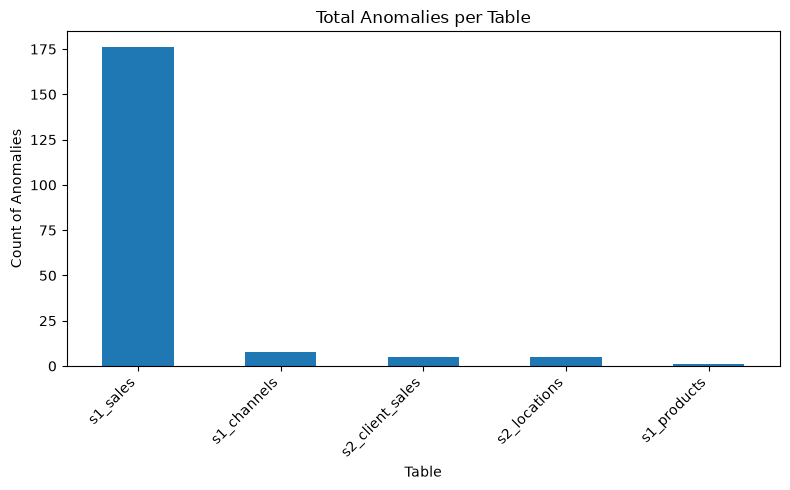

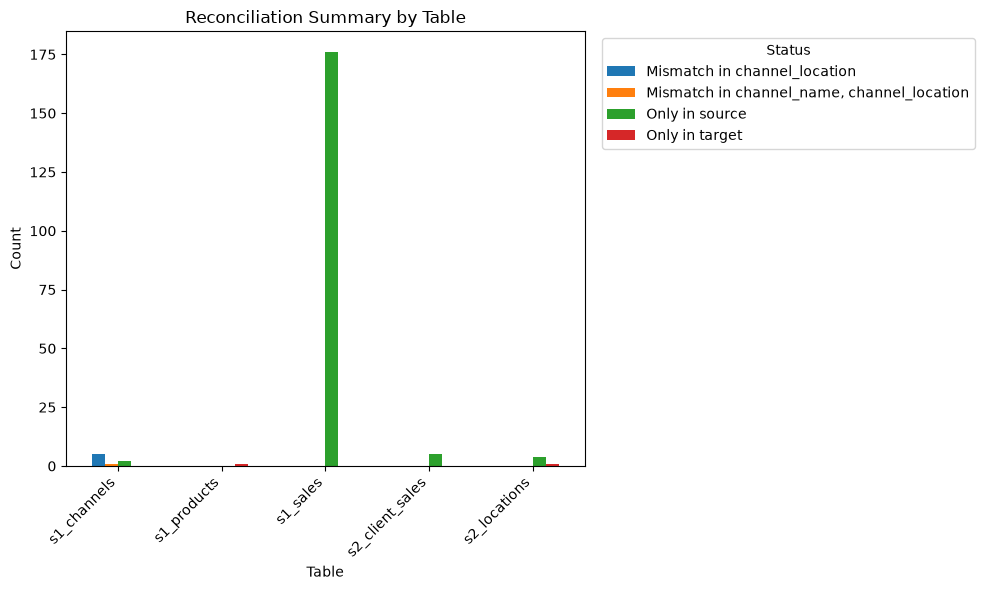

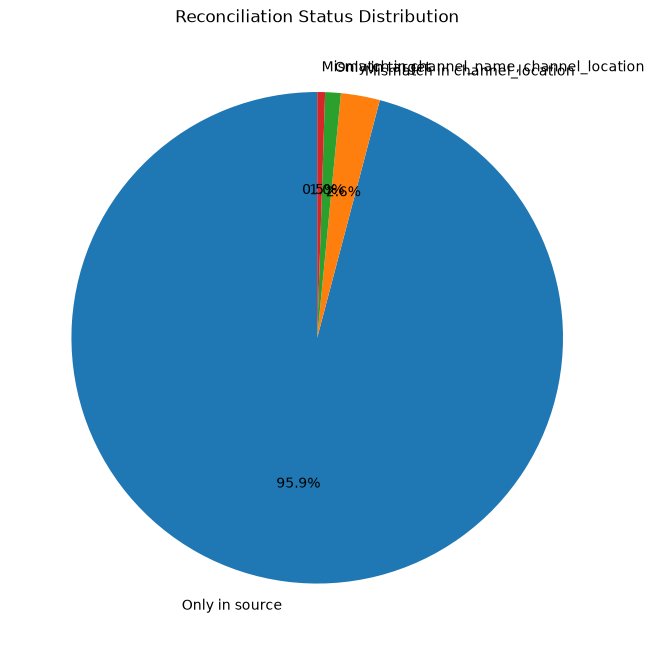

In [24]:
import matplotlib.pyplot as plt

# 1) Total anomalies per table -----------------------------------------------
anomalies_per_table = final_reconciliation_df.groupby('table_name').size().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
anomalies_per_table.plot(kind='bar', color='#1f77b4')
plt.title('Total Anomalies per Table')
plt.xlabel('Table')
plt.ylabel('Count of Anomalies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2) Reconciliation summary by table (status breakdown per table) ------------
summary = final_reconciliation_df.groupby(['table_name', 'reconciliation_status']).size().unstack(fill_value=0)

summary.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title('Reconciliation Summary by Table')
plt.xlabel('Table')
plt.ylabel('Count')
plt.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3) Overall reconciliation status distribution -------------------------------
status_counts = final_reconciliation_df['reconciliation_status'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Reconciliation Status Distribution')
plt.tight_layout()
plt.show()